# Cloud feedback assessment
- Assign weights to studies that represent various categories of methods
- Use a mixture model to assess a combined distribution for each cloud feedback
- Assume feedbacks are independent and combine to a total uncertainty

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import erf, pi, sqrt
from IPython.display import display

# Notes

### Weighted mixture model

We represented each study as a normal distribution centered on its feedback estimate, with a spread given by its reported standard deviation. Where uncertainty was reported as a 90% confidence-interval half-width, it was converted to a standard deviation by dividing by 1.645.

The studies were combined using a weighted mixture model. On each Monte Carlo iteration, one study was selected at random, with its probability of selection equal to its normalized weight. A feedback value was then drawn from the selected study’s normal distribution. This process was repeated $10^6$ times to obtain the combined feedback distribution:

$$
p(\lambda)=\sum_i w_i\,\mathcal{N}(\lambda\mid\mu_i,\sigma_i^2),
$$

where $\mu_i$, $\sigma_i$, and $w_i$ are the feedback estimate, standard deviation, and normalized weight for study $i$, respectively. Studies assigned zero weight were excluded.

This approach preserves both the uncertainty within each study and the differences among study estimates. We summarized each mixture using its mean, median, standard deviation, central 66% interval, and 5th–95th percentile range.

To calculate total cloud feedback, we assumed that the low-cloud, high-cloud altitude, high-cloud amount and optical-depth, land-cloud, and unassessed-cloud feedbacks were independent. The unassessed-cloud component is represented by $\mathcal{N}(0, 0.1^2)$ W m$^{-2}$ K$^{-1}$. One draw from each component distribution was summed on every iteration, producing the distribution of total cloud feedback.

### What is the difference between the old and new method?
#### Old monte carlo method
Asks: What is the uncertainty in the weighted average of all study-specific values?

#### New mixture model
Asks: What values are plausible if one of these study distributions represents the true feedback?

# High Cloud (altitude and amount+$\tau$)

Amount and optical-depth feedback:


,Reference,Feedback,STD,Weight,Note
0,Stauffer et al (2024),0.07,0.130,0.25,Multiplied by factor of 0.33 to account for tr...
1,Sokol et al (2024),0.03,0.060,0.00,Subsumed into Stauffer estimate
2,Chao et al (2026),0.01,0.020,0.08,Combined anvil + trop marine descent high clou...
3,Deutloff et al (2026),-0.01,0.020,0.02,CRE feedback is combination of +2K and +4K aqu...
4,Raghuraman & Medeiros (2026),0.00,0.030,0.18,"Short-term using FBCT, CRK, and ERF adjustments."
5,Raghuraman et al. (2024),0.01,0.054,0.00,Short-term. Superseded Raghuraman & Medeiros (...
6,McKim et al (2024),0.05,0.080,0.11,"Combined McKim area estimate (0.02,0.07) with ..."
7,Chao et al (2024),0.05,0.050,0.14,Combination of anvil cloud feedback over ascen...
8,Van de Koot et al (2025) variability,-0.14,0.110,0.00,Subsumed into other short-term estimates. Esti...
9,Wilson-Kemsley et al (2025),-0.01,0.080,0.15,"Combined area estimate (-0.04,0.065) with Ragh..."



High-cloud-altitude feedback:


,Reference,Feedback,STD,Weight,Note
0,Sherwood et al (2020),0.20,0.10,0.50,Sherwood 2020 based on Zelinka et al 2016
1,Stauffer et al (2024),0.20,0.14,0.10,Tropical value assumed to apply over whole globe
2,Chao et al (2026),0.36,0.04,0.10,3km SCREAM. CI is combination of structural di...
3,Deutloff et al (2026),0.28,0.08,0.02,CRE feedback from ICON aquaplanet. Tropical al...
4,Raghuraman et al (2024),0.12,0.01,0.00,Superseded by Raghuraman & Medeiros (2026)
5,Raghuraman & Medeiros (2026),0.16,0.02,0.12,Confidence intervals are personal communication.
6,Chao et al (2024),0.42,0.05,0.12,Interannual. (CI from Paulo's sheet)
7,Aerenson & Marchand (2025),0.24,0.02,0.04,GCM emergent constraint.



Exact normal-mixture results:


,Mean,STD,2.5%,5%,16.5%,Median,83.5%,95%,97.5%,P(Feedback > 0)
Amount and optical depth,0.0141,0.1180,-0.3042,-0.1743,-0.0495,0.0151,0.1009,0.1904,0.2400,0.6053
High-cloud altitude,0.2408,0.1212,0.0141,0.0529,0.1317,0.2283,0.3756,0.4421,0.4685,0.9810



Monte Carlo check using 1,000,000 draws:


,Mean,STD,2.5%,5%,16.5%,Median,83.5%,95%,97.5%,P(Feedback > 0)
Amount and optical depth,0.0142,0.1180,-0.3042,-0.1737,-0.0494,0.0151,0.1010,0.1900,0.2397,0.6056
High-cloud altitude,0.2409,0.1214,0.0141,0.0526,0.1316,0.2285,0.3759,0.4424,0.4691,0.9810


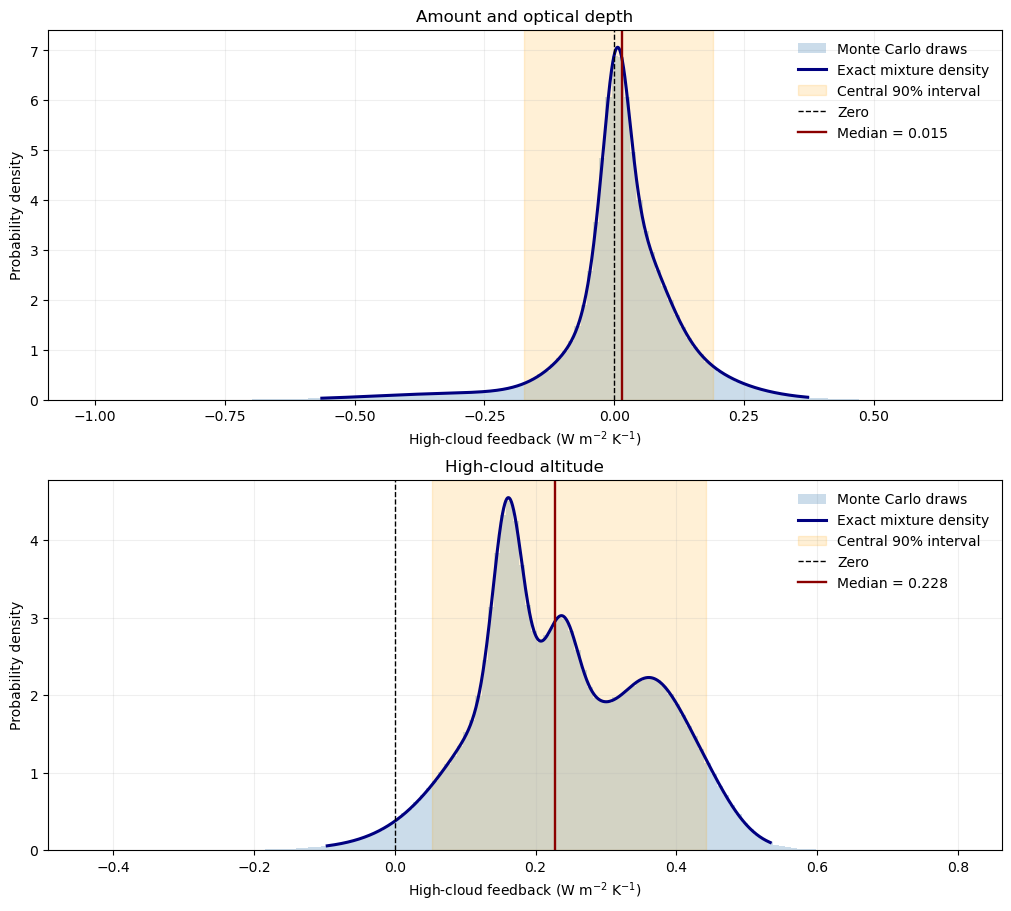

In [3]:

# ============================================================
# 1. Editable input tables
# ============================================================

amount_optical_depth_df = pd.DataFrame([
    {
        "Reference": "Stauffer et al (2024)",
        "Feedback": 0.07,
        "STD": 0.13,
        "Weight": 0.25,
        "Note": (
            "Multiplied by factor of 0.33 to account for tropical ocean "
            "surface area (37%) and 0.9 K warming per degree GMST change"
        ),
    },
    {
        "Reference": "Sokol et al (2024)",
        "Feedback": 0.03,
        "STD": 0.06,
        "Weight": 0.00,
        "Note": "Subsumed into Stauffer estimate",
    },
    {
        "Reference": "Chao et al (2026)",
        "Feedback": 0.01,
        "STD": 0.02,
        "Weight": 0.08,
        "Note": (
            "Combined anvil + trop marine descent high cloud values from"
            "Table 1. CI is combination of structural diff of 0.016 between"
            "3km and 12km runs and st dev of 0.003 across 12km ensemble "
            "(those values from emails with Li-Wei)."
        )
    },
    {
        "Reference": "Deutloff et al (2026)",
        "Feedback": -0.01,
        "STD": 0.02,
        "Weight": 0.02,
        "Note": (
            "CRE feedback is combination of +2K and +4K aquaplanet runs taken"
            "from Table 1 in Jakob's thesis. CI is an arbitrary filler copied "
            "from Chao GSRM study; Jakob does not have a quantitative estimate"
            "but thinks it's low. Weight low for now as we do not have a good CI"
            "estimates these are CRE feedbacks. "
        ),
    },
    {
        "Reference": "Raghuraman & Medeiros (2026)",
        "Feedback": 0.00,
        "STD": 0.03,
        "Weight": 0.18,
        "Note": "Short-term using FBCT, CRK, and ERF adjustments.",
    },
    {
        "Reference": "Raghuraman et al. (2024)",
        "Feedback": 0.01,
        "STD": 0.054,
        "Weight": 0.00,
        "Note": "Short-term. Superseded Raghuraman & Medeiros (2026)",
    },
    {
        "Reference": "McKim et al (2024)",
        "Feedback": 0.05,
        "STD": 0.08,
        "Weight": 0.11,
        "Note": (
            "Combined McKim area estimate (0.02,0.07) with Raghuraman 2024 OD "
            "estimate (0.03,0.045). Shaved a few points off of weight "
            "because of dependence on Raghuraman's OD component"
        ),
    },
    {
        "Reference": "Chao et al (2024)",
        "Feedback": 0.05,
        "STD": 0.05,
        "Weight": 0.14,
        "Note": (
            "Combination of anvil cloud feedback over ascent regions (0.01) "
            "and descent regions (0.04). Uncertainties (0.05 and 0.06) "
            "added in quadrature then scaled from 90% to 66%"
        ),
    },
    {
        "Reference": "Van de Koot et al (2025) variability",
        "Feedback": -0.14,
        "STD": 0.11,
        "Weight": 0.00,
        "Note": (
            "Subsumed into other short-term estimates. Estimate reflects all "
            "clouds in ascent regions only (high clouds not isolated)."
        ),
    },
    {
        "Reference": "Wilson-Kemsley et al (2025)",
        "Feedback": -0.01,
        "STD": 0.08,
        "Weight": 0.15,
        "Note": (
            "Combined area estimate (-0.04,0.065) with Raghuraman OD "
            "estimate (0.03,0.045)"
        ),
    },
    {
        "Reference": "Aerenson & Marchand (2025)",
        "Feedback": 0.00,
        "STD": 0.04,
        "Weight": 0.02,
        "Note": (
            "No scaling necessary (from Travis via Paulo). Low weight "
            "due to reliance on small number of GCMs"
        ),
    },
    {
        "Reference": "Van de Koot et al (2025) trend",
        "Feedback": -0.30,
        "STD": 0.16,
        "Weight": 0.05,
        "Note": (
            "Trend calculated from all clouds in tropical ocean ascent regions, "
            "with altitude feedback removes using Sherwood (2020) estimate."
        )
    },
])


high_cloud_altitude_df = pd.DataFrame([
    {
        "Reference": "Sherwood et al (2020)",
        "Feedback": 0.20,
        "STD": 0.10,
        "Weight": 0.50,
        "Note": "Sherwood 2020 based on Zelinka et al 2016",
    },
    {
        "Reference": "Stauffer et al (2024)",
        "Feedback": 0.20,
        "STD": 0.14,
        "Weight": 0.10,
        "Note": "Tropical value assumed to apply over whole globe",
    },
    {
        "Reference": "Chao et al (2026)",
        "Feedback": 0.36,
        "STD": 0.04,
        "Weight": 0.10,
        "Note": (
            "3km SCREAM. CI is combination of structural diff of 0.04 between "
            "3km and 12km runs and st dev of 0.005 across the 12km ensemble."
            "Giving it similar weight to RCEMIP even though it is a single model "
            "because it is global"
        ),
    },
    {
        "Reference": "Deutloff et al (2026)",
        "Feedback": 0.28,
        "STD": 0.08,
        "Weight": 0.02,
        "Note": (
            "CRE feedback from ICON aquaplanet. Tropical altitude feedback "
            "assumed to apply to extratropics. Mean is average of +2K and +4K "
            "runs, CI is structural difference between the two runs."
        ),
    },
    {
        "Reference": "Raghuraman et al (2024)",
        "Feedback": 0.12,
        "STD": 0.01,
        "Weight": 0.00,
        "Note": "Superseded by Raghuraman & Medeiros (2026)",
    },
    {
        "Reference": "Raghuraman & Medeiros (2026)",
        "Feedback": 0.16,
        "STD": 0.02,
        "Weight": 0.12,
        "Note": "Confidence intervals are personal communication.",
    },
    {
        "Reference": "Chao et al (2024)",
        "Feedback": 0.42,
        "STD": 0.05,
        "Weight": 0.12,
        "Note": "Interannual. (CI from Paulo's sheet)",
    },
    {
        "Reference": "Aerenson & Marchand (2025)",
        "Feedback": 0.24,
        "STD": 0.02,
        "Weight": 0.04,
        "Note": "GCM emergent constraint.",
    },
])


# Display the editable input tables
print("Amount and optical-depth feedback:")
display(amount_optical_depth_df)

print("\nHigh-cloud-altitude feedback:")
display(high_cloud_altitude_df)


# ============================================================
# 2. Mixture-model functions
# ============================================================

SQRT_2 = sqrt(2.0)
SQRT_2PI = sqrt(2.0 * pi)


def get_components(df):
    """
    Extract the positive-weight mixture components and normalize their weights.
    """
    required = {"Reference", "Feedback", "STD", "Weight"}
    missing = required.difference(df.columns)

    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    if (df["Weight"] < 0).any():
        raise ValueError("Weights cannot be negative.")

    active = df.loc[df["Weight"] > 0].copy()

    if active.empty:
        raise ValueError("At least one weight must be greater than zero.")

    if (active["STD"] <= 0).any():
        raise ValueError("Every active study must have STD > 0.")

    means = active["Feedback"].to_numpy(dtype=float)
    stds = active["STD"].to_numpy(dtype=float)
    weights = active["Weight"].to_numpy(dtype=float)
    weights /= weights.sum()

    return active, means, stds, weights


def mixture_pdf(x, means, stds, weights):
    """
    Evaluate the density of a normal mixture.
    """
    x = np.asarray(x, dtype=float)

    z = (
        x[:, np.newaxis] - means[np.newaxis, :]
    ) / stds[np.newaxis, :]

    component_densities = (
        np.exp(-0.5 * z**2)
        / (stds[np.newaxis, :] * SQRT_2PI)
    )

    return np.sum(
        weights[np.newaxis, :] * component_densities,
        axis=1,
    )


def mixture_cdf(x, means, stds, weights):
    """
    Evaluate the mixture CDF at one scalar value.
    """
    return sum(
        weight * 0.5 * (
            1.0 + erf((x - mean) / (std * SQRT_2))
        )
        for mean, std, weight in zip(means, stds, weights)
    )


def mixture_quantile(probability, means, stds, weights):
    """
    Numerically invert the mixture CDF using bisection.
    """
    if not 0 < probability < 1:
        raise ValueError("Probability must be between zero and one.")

    lower = np.min(means - 12.0 * stds)
    upper = np.max(means + 12.0 * stds)

    # One hundred iterations is far more precision than needed here.
    for _ in range(100):
        midpoint = 0.5 * (lower + upper)

        if mixture_cdf(midpoint, means, stds, weights) < probability:
            lower = midpoint
        else:
            upper = midpoint

    return 0.5 * (lower + upper)


def exact_mixture_summary(df):
    """
    Deterministic summary of the weighted normal mixture.

    This does not depend on the random seed or number of Monte Carlo draws.
    """
    _, means, stds, weights = get_components(df)

    mixture_mean = np.sum(weights * means)

    # E[X^2] - E[X]^2
    mixture_variance = (
        np.sum(weights * (stds**2 + means**2))
        - mixture_mean**2
    )

    probabilities = [0.025, 0.05, 0.165, 0.50, 0.835, 0.95, 0.975]

    quantiles = {
        probability: mixture_quantile(
            probability, means, stds, weights
        )
        for probability in probabilities
    }

    probability_positive = (
        1.0 - mixture_cdf(0.0, means, stds, weights)
    )

    return pd.Series({
        "Mean": mixture_mean,
        "STD": sqrt(mixture_variance),
        "2.5%": quantiles[0.025],
        "5%": quantiles[0.05],
        "16.5%": quantiles[0.165],
        "Median": quantiles[0.50],
        "83.5%": quantiles[0.835],
        "95%": quantiles[0.95],
        "97.5%": quantiles[0.975],
        "P(Feedback > 0)": probability_positive,
    })


def sample_study_mixture(df, n_samples=1_000_000, random_seed=123):
    """
    Bayesian model-averaging simulation:

        1. Select one study using the normalized weights.
        2. Draw once from the selected study's distribution.
    """
    active, means, stds, weights = get_components(df)
    rng = np.random.default_rng(random_seed)

    selected_studies = rng.choice(
        len(active),
        size=n_samples,
        replace=True,
        p=weights,
    )

    draws = rng.normal(
        loc=means[selected_studies],
        scale=stds[selected_studies],
    )

    selected_references = (
        active["Reference"].to_numpy()[selected_studies]
    )

    return draws, selected_references


def monte_carlo_summary(draws):
    """
    Summary calculated directly from the simulated draws.
    """
    q = np.percentile(
        draws,
        [2.5, 5, 16.5, 50, 83.5, 95, 97.5],
    )

    return pd.Series({
        "Mean": np.mean(draws),
        "STD": np.std(draws, ddof=0),
        "2.5%": q[0],
        "5%": q[1],
        "16.5%": q[2],
        "Median": q[3],
        "83.5%": q[4],
        "95%": q[5],
        "97.5%": q[6],
        "P(Feedback > 0)": np.mean(draws > 0),
    })


# ============================================================
# 3. Calculate the two distributions
# ============================================================

feedback_tables = {
    "Amount and optical depth": amount_optical_depth_df,
    "High-cloud altitude": high_cloud_altitude_df,
}

# Exact, deterministic mixture results
exact_results = pd.DataFrame({
    name: exact_mixture_summary(df)
    for name, df in feedback_tables.items()
}).T

print("\nExact normal-mixture results:")
display(exact_results.round(4))


# Monte Carlo results, used as a numerical check
N_SAMPLES = 1_000_000
samples = {}

for seed, (name, df) in enumerate(feedback_tables.items(), start=42):
    draws, selected_references = sample_study_mixture(
        df,
        n_samples=N_SAMPLES,
        random_seed=seed,
    )
    samples[name] = draws

mc_results = pd.DataFrame({
    name: monte_carlo_summary(draws)
    for name, draws in samples.items()
}).T

print(f"\nMonte Carlo check using {N_SAMPLES:,} draws:")
display(mc_results.round(4))


# ============================================================
# 4. Plot the results
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 9),
    constrained_layout=True,
)

for ax, (name, df) in zip(axes, feedback_tables.items()):
    _, means, stds, weights = get_components(df)
    summary = exact_mixture_summary(df)
    draws = samples[name]

    x_lower = mixture_quantile(
        0.0025, means, stds, weights
    )
    x_upper = mixture_quantile(
        0.9975, means, stds, weights
    )
    x = np.linspace(x_lower, x_upper, 1_500)
    density = mixture_pdf(x, means, stds, weights)

    # Monte Carlo histogram
    ax.hist(
        draws,
        bins=140,
        density=True,
        color="steelblue",
        alpha=0.28,
        edgecolor="none",
        label="Monte Carlo draws",
    )

    # Exact mixture density
    ax.plot(
        x,
        density,
        color="navy",
        linewidth=2.2,
        label="Exact mixture density",
    )

    # Central 90% interval
    ax.axvspan(
        summary["5%"],
        summary["95%"],
        color="orange",
        alpha=0.16,
        label="Central 90% interval",
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Zero",
    )

    ax.axvline(
        summary["Median"],
        color="darkred",
        linewidth=1.7,
        label=f'Median = {summary["Median"]:.3f}',
    )

    ax.set_title(name)
    ax.set_xlabel(
        r"High-cloud feedback (W m$^{-2}$ K$^{-1}$)"
    )
    ax.set_ylabel("Probability density")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

plt.show()

# Low cloud (near-global marine)

,Reference,Region Analyzed,Feedback (scaled to global),90% CI,Weight,Comments
0,Sherwood et al (2020),summing 3 assessed low cloud regimes,0.37,0.3619,0.05,1 sigma uncertainty converted to 90% CI; estim...
1,Cesana & Del Genio (2021),"30S-30N, ocean",0.14,0.0480,0.00,Local CCF analysis (SST+EIS only predictors); ...
2,Myers et al (2021),60S-60N ocean,0.19,0.1200,0.00,Local CCF analysis (6 predictors); CRK to extr...
3,Zelinka et al (submitted),60S-60N ocean,0.21,0.2300,0.30,Local CCF analysis (6 predictors); CRK to extr...
4,Ceppi and Nowack (2021),"global, ocean",0.07,0.1600,0.00,Regional CCF analysis (5 predictors); adjusted...
5,"Ceppi et al (2024), land+ocean","60S-60N, land+ocean",0.45,0.2700,0.00,Regional CCF analysis (6 predictors); CRK to e...
6,"Ceppi et al (2024), ocean","60S-60N, ocean",0.42,0.3000,0.50,Regional CCF analysis (6 predictors); CRK to e...
7,Wilson-Kemsley et al. (2026),"60S-60N, land+ocean",0.46,0.1600,0.00,Regional CCF analysis (6 predictors); CRK to e...
8,Ceppi et al (2026),"60S-60N, land+ocean",0.37,NaN,0.00,Regional CCF analysis (6 predictors); SW only;...
9,Chao et al (2024),summing 3 S20-assessed low cloud regimes,0.01,0.1500,0.05,Straight interannual variability; not a CCF st...


Studies used in the mixture:


,Reference,Region Analyzed,Feedback (scaled to global),90% CI,Weight,Comments,STD,Normalized Weight
0,Sherwood et al (2020),summing 3 assessed low cloud regimes,0.370,0.3619,0.05,1 sigma uncertainty converted to 90% CI; estim...,0.220020,0.05
1,Zelinka et al (submitted),60S-60N ocean,0.210,0.2300,0.30,Local CCF analysis (6 predictors); CRK to extr...,0.139830,0.30
2,"Ceppi et al (2024), ocean","60S-60N, ocean",0.420,0.3000,0.50,Regional CCF analysis (6 predictors); CRK to e...,0.182387,0.50
3,Chao et al (2024),summing 3 S20-assessed low cloud regimes,0.010,0.1500,0.05,Straight interannual variability; not a CCF st...,0.091194,0.05
4,Ma et al (2026),40S-40N,0.330,0.2100,0.05,Linking percentage cloud change to surface-oce...,0.127671,0.05
5,"Chao et al (2026), combined","60S-60N, ocean",0.025,0.1750,0.05,Derived from the 3 km and 12 km estimates. Fee...,0.106392,0.05


,Exact mixture,Monte Carlo check
Mean,0.3097,0.3101
STD,0.2110,0.2110
2.5%,-0.0787,-0.0783
5%,-0.0297,-0.0298
16.5%,0.0944,0.0947
Median,0.3063,0.3067
83.5%,0.5206,0.5211
95%,0.6644,0.6641
97.5%,0.7297,0.7297
P(Feedback > 0),0.9290,0.9288


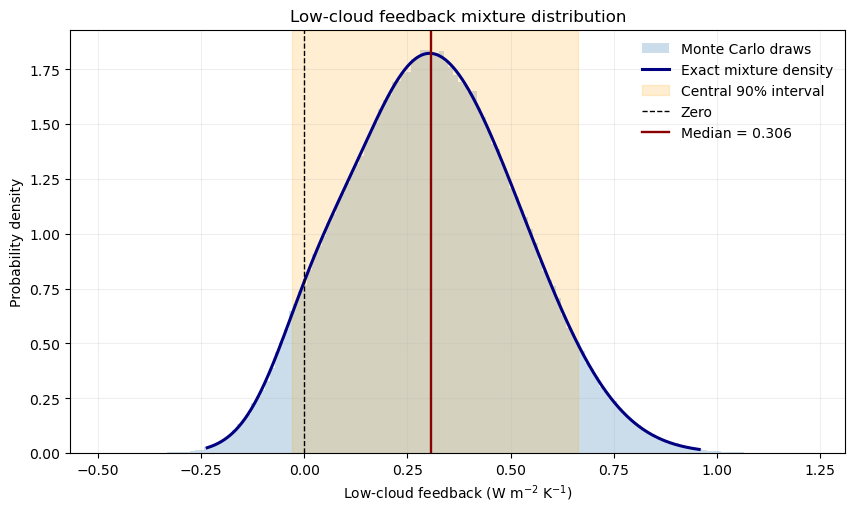

In [4]:
# ============================================================
# 1. Editable source table
# ============================================================

low_cloud_source_df = pd.DataFrame([
    {
        "Reference": "Sherwood et al (2020)",
        "Region Analyzed": "summing 3 assessed low cloud regimes",
        "Feedback (scaled to global)": 0.37,
        "90% CI": 0.3619,
        "Weight": 0.05,
        "Comments": (
            "1 sigma uncertainty converted to 90% CI; "
            "estimated via summing in quadrature"
        ),
    },
    {
        "Reference": "Cesana & Del Genio (2021)",
        "Region Analyzed": "30S-30N, ocean",
        "Feedback (scaled to global)": 0.14,
        "90% CI": 0.048,
        "Weight": 0.00,
        "Comments": (
            "Local CCF analysis (SST+EIS only predictors); SW only; "
            "scaled by 0.25 (descending half of the tropics); "
            "CI converted from 80% to 90% via factor of 1.28"
        ),
    },
    {
        "Reference": "Myers et al (2021)",
        "Region Analyzed": "60S-60N ocean",
        "Feedback (scaled to global)": 0.19,
        "90% CI": 0.12,
        "Weight": 0.00,
        "Comments": (
            "Local CCF analysis (6 predictors); "
            "CRK to extract low-cloud feedbacks"
        ),
    },
    {
        "Reference": "Zelinka et al (submitted)",
        "Region Analyzed": "60S-60N ocean",
        "Feedback (scaled to global)": 0.21,
        "90% CI": 0.23,
        "Weight": 0.30,
        "Comments": (
            "Local CCF analysis (6 predictors); "
            "CRK to extract low-cloud feedbacks. "
            "Labeled Zelinka et al. (2026) in the screenshot."
        ),
    },
    {
        "Reference": "Ceppi and Nowack (2021)",
        "Region Analyzed": "global, ocean",
        "Feedback (scaled to global)": 0.07,
        "90% CI": 0.16,
        "Weight": 0.00,
        "Comments": (
            "Regional CCF analysis (5 predictors); adjusted delta-CRE "
            "+ Webb method to infer low-cloud contribution"
        ),
    },
    {
        "Reference": "Ceppi et al (2024), land+ocean",
        "Region Analyzed": "60S-60N, land+ocean",
        "Feedback (scaled to global)": 0.45,
        "90% CI": 0.27,
        "Weight": 0.00,
        "Comments": (
            "Regional CCF analysis (6 predictors); "
            "CRK to extract low-cloud feedbacks"
        ),
    },
    {
        "Reference": "Ceppi et al (2024), ocean",
        "Region Analyzed": "60S-60N, ocean",
        "Feedback (scaled to global)": 0.42,
        "90% CI": 0.30,
        "Weight": 0.50,
        "Comments": (
            "Regional CCF analysis (6 predictors); "
            "CRK to extract low-cloud feedbacks"
        ),
    },
    {
        "Reference": "Wilson-Kemsley et al. (2026)",
        "Region Analyzed": "60S-60N, land+ocean",
        "Feedback (scaled to global)": 0.46,
        "90% CI": 0.16,
        "Weight": 0.00,
        "Comments": (
            "Regional CCF analysis (6 predictors); "
            "CRK to extract low-cloud feedbacks"
        ),
    },
    {
        "Reference": "Ceppi et al (2026)",
        "Region Analyzed": "60S-60N, land+ocean",
        "Feedback (scaled to global)": 0.37,
        "90% CI": np.nan,
        "Weight": 0.00,
        "Comments": (
            "Regional CCF analysis (6 predictors); SW only; CRK to "
            "extract low-cloud component; CCF trends from "
            "historical+ssp245 MMM, normalized by observed warming"
        ),
    },
    {
        "Reference": "Chao et al (2024)",
        "Region Analyzed": "summing 3 S20-assessed low cloud regimes",
        "Feedback (scaled to global)": 0.01,
        "90% CI": 0.15,
        "Weight": 0.05,
        "Comments": (
            "Straight interannual variability; not a CCF study; "
            "CRK to extract low-cloud feedbacks"
        ),
    },
    {
        "Reference": "Chao et al (2026), 3 km",
        "Region Analyzed": "60S-60N, ocean",
        "Feedback (scaled to global)": 0.20,
        "90% CI": np.nan,
        "Weight": 0.00,
        "Comments": (
            "SCREAM 3 km GSRM uniform +4 K experiment (1 year); "
            "combined with the 12 km result below for analysis"
        ),
    },
    {
        "Reference": "Chao et al (2026), 12 km",
        "Region Analyzed": "60S-60N, ocean",
        "Feedback (scaled to global)": -0.15,
        "90% CI": np.nan,
        "Weight": 0.00,
        "Comments": (
            "SCREAM 12 km GSRM uniform +4 K experiment (1 year); "
            "combined with the 3 km result above for analysis"
        ),
    },
    {
        "Reference": "Wu et al (2025)",
        "Region Analyzed": "SEP and SEA Sc regions",
        "Feedback (scaled to global)": 0.18,
        "90% CI": np.nan,
        "Weight": 0.00,
        "Comments": (
            "Pareto weighting of CMIP models with best dCRE/dSST and "
            "dCRE/dT700 relative to observations in two Sc regions; "
            "tropical-mean SW feedback only; halved for global contribution"
        ),
    },
    {
        "Reference": "Ma et al (2026)",
        "Region Analyzed": "40S-40N",
        "Feedback (scaled to global)": 0.33,
        "90% CI": 0.21,
        "Weight": 0.05,
        "Comments": (
            "Linking percentage cloud change to surface-ocean "
            "warming patterns"
        ),
    },
])

display(low_cloud_source_df)


# ============================================================
# 2. Construct the analysis table
# ============================================================

# For a central normal 90% interval:
# CI half-width = 1.64485 * standard deviation
NORMAL_90 = 1.6448536269514722

# Copy directly included studies.
low_cloud_analysis_df = low_cloud_source_df.loc[
    low_cloud_source_df["Weight"] > 0
].copy()

# Combine the two Chao et al. (2026) estimates as shown in the screenshot:
#
# midpoint   = (0.20 + -0.15) / 2 = 0.025
# half-range = (0.20 - -0.15) / 2 = 0.175
#
# The half-range is treated as a 90% CI half-width.
chao_2026_combined = pd.DataFrame([{
    "Reference": "Chao et al (2026), combined",
    "Region Analyzed": "60S-60N, ocean",
    "Feedback (scaled to global)": (0.20 + -0.15) / 2,
    "90% CI": (0.20 - -0.15) / 2,
    "Weight": 0.05,
    "Comments": (
        "Derived from the 3 km and 12 km estimates. Feedback is their "
        "midpoint and the 90% CI half-width is their half-range."
    ),
}])

low_cloud_analysis_df = pd.concat(
    [low_cloud_analysis_df, chao_2026_combined],
    ignore_index=True,
)

low_cloud_analysis_df["STD"] = (
    low_cloud_analysis_df["90% CI"] / NORMAL_90
)

# Normalize weights automatically in case you edit them later.
low_cloud_analysis_df["Normalized Weight"] = (
    low_cloud_analysis_df["Weight"]
    / low_cloud_analysis_df["Weight"].sum()
)

print("Studies used in the mixture:")
display(low_cloud_analysis_df)


# ============================================================
# 3. Mixture-model functions
# ============================================================

SQRT_2 = sqrt(2.0)
SQRT_2PI = sqrt(2.0 * pi)


def get_components(df):
    means = df["Feedback (scaled to global)"].to_numpy(float)
    stds = df["STD"].to_numpy(float)
    weights = df["Weight"].to_numpy(float)

    if np.any(stds <= 0) or np.any(~np.isfinite(stds)):
        raise ValueError("Every included study must have a finite STD > 0.")

    if np.any(weights < 0) or weights.sum() <= 0:
        raise ValueError("Weights must be nonnegative and sum to > 0.")

    weights = weights / weights.sum()
    return means, stds, weights


def normal_cdf(x, mean, std):
    return 0.5 * (
        1.0 + erf((x - mean) / (std * SQRT_2))
    )


def mixture_cdf(x, means, stds, weights):
    return sum(
        weight * normal_cdf(x, mean, std)
        for mean, std, weight in zip(means, stds, weights)
    )


def mixture_pdf(x, means, stds, weights):
    x = np.asarray(x)

    z = (
        x[:, np.newaxis] - means[np.newaxis, :]
    ) / stds[np.newaxis, :]

    component_densities = (
        np.exp(-0.5 * z**2)
        / (stds[np.newaxis, :] * SQRT_2PI)
    )

    return np.sum(
        weights[np.newaxis, :] * component_densities,
        axis=1,
    )


def mixture_quantile(probability, means, stds, weights):
    lower = np.min(means - 12 * stds)
    upper = np.max(means + 12 * stds)

    for _ in range(100):
        midpoint = (lower + upper) / 2

        if mixture_cdf(
            midpoint, means, stds, weights
        ) < probability:
            lower = midpoint
        else:
            upper = midpoint

    return (lower + upper) / 2


def exact_mixture_summary(df):
    means, stds, weights = get_components(df)

    mean = np.sum(weights * means)
    variance = (
        np.sum(weights * (stds**2 + means**2))
        - mean**2
    )

    probabilities = [
        0.025, 0.05, 0.165, 0.50,
        0.835, 0.95, 0.975,
    ]

    q = {
        p: mixture_quantile(p, means, stds, weights)
        for p in probabilities
    }

    return pd.Series({
        "Mean": mean,
        "STD": sqrt(variance),
        "2.5%": q[0.025],
        "5%": q[0.05],
        "16.5%": q[0.165],
        "Median": q[0.50],
        "83.5%": q[0.835],
        "95%": q[0.95],
        "97.5%": q[0.975],
        "P(Feedback > 0)": (
            1 - mixture_cdf(0, means, stds, weights)
        ),
    })


def sample_study_mixture(
    df,
    n_samples=500_000,
    random_seed=42,
):
    """
    On each iteration:
      1. Select one study according to its weight.
      2. Draw from that study's normal distribution.
    """
    means, stds, weights = get_components(df)
    rng = np.random.default_rng(random_seed)

    selected_studies = rng.choice(
        len(df),
        size=n_samples,
        p=weights,
    )

    draws = rng.normal(
        loc=means[selected_studies],
        scale=stds[selected_studies],
    )

    return draws, selected_studies


# ============================================================
# 4. Calculate exact and Monte Carlo results
# ============================================================

exact_results = exact_mixture_summary(
    low_cloud_analysis_df
)

draws, selected_studies = sample_study_mixture(
    low_cloud_analysis_df,
    n_samples=500_000,
    random_seed=42,
)

mc_percentiles = np.percentile(
    draws,
    [2.5, 5, 16.5, 50, 83.5, 95, 97.5],
)

monte_carlo_results = pd.Series({
    "Mean": draws.mean(),
    "STD": draws.std(),
    "2.5%": mc_percentiles[0],
    "5%": mc_percentiles[1],
    "16.5%": mc_percentiles[2],
    "Median": mc_percentiles[3],
    "83.5%": mc_percentiles[4],
    "95%": mc_percentiles[5],
    "97.5%": mc_percentiles[6],
    "P(Feedback > 0)": np.mean(draws > 0),
})

results = pd.DataFrame({
    "Exact mixture": exact_results,
    "Monte Carlo check": monte_carlo_results,
})

display(results.round(4))


# ============================================================
# 5. Plot the resulting mixture
# ============================================================

means, stds, weights = get_components(
    low_cloud_analysis_df
)

x = np.linspace(
    mixture_quantile(0.001, means, stds, weights),
    mixture_quantile(0.999, means, stds, weights),
    1_500,
)

density = mixture_pdf(x, means, stds, weights)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.hist(
    draws,
    bins=150,
    density=True,
    color="steelblue",
    alpha=0.28,
    edgecolor="none",
    label="Monte Carlo draws",
)

ax.plot(
    x,
    density,
    color="navy",
    linewidth=2.2,
    label="Exact mixture density",
)

ax.axvspan(
    exact_results["5%"],
    exact_results["95%"],
    color="orange",
    alpha=0.18,
    label="Central 90% interval",
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Zero",
)

ax.axvline(
    exact_results["Median"],
    color="darkred",
    linewidth=1.7,
    label=f'Median = {exact_results["Median"]:.3f}',
)

ax.set_title("Low-cloud feedback mixture distribution")
ax.set_xlabel(
    r"Low-cloud feedback (W m$^{-2}$ K$^{-1}$)"
)
ax.set_ylabel("Probability density")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.show()

# Combine mixture-assessed cloud components

Three-component cloud-feedback distribution


,Estimate
Mean,0.5652
Median,0.5648
STD,0.2705
2.5%,0.0381
5%,0.1238
16.5%,0.3029
83.5%,0.8293
95%,1.0092
97.5%,1.0931
P(Combined feedback > 0),0.9820


Central 68% interval: [0.303, 0.829]
Central 90% interval: [0.124, 1.009]
Central 95% interval: [0.038, 1.093]


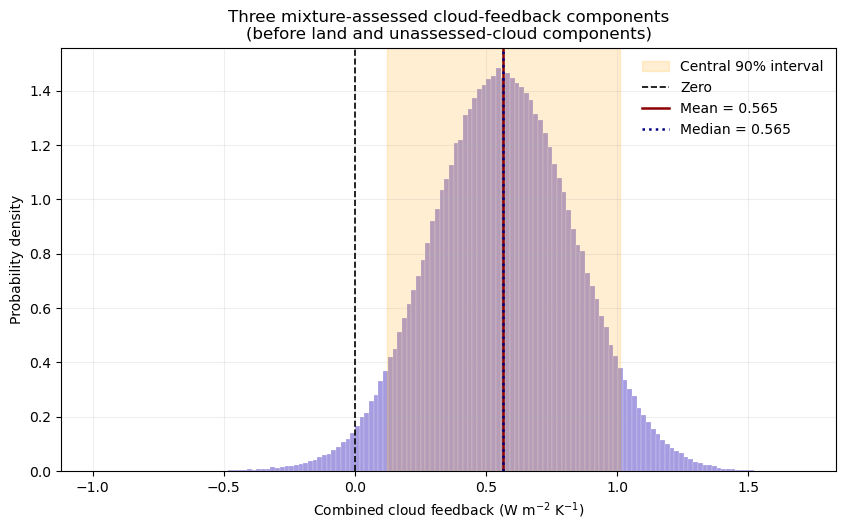

In [5]:
# ============================================================
# Intermediate cell: combine the three mixture-assessed components
# ============================================================

# Variables produced by the earlier cells:
#   samples["Amount and optical depth"]
#   samples["High-cloud altitude"]
#   draws  -> low-cloud mixture draws

component_draws = {
    "High-cloud amount and optical depth": np.asarray(
        samples["Amount and optical depth"]
    ),
    "High-cloud altitude": np.asarray(
        samples["High-cloud altitude"]
    ),
    "Low-cloud": np.asarray(draws),
}

# Use a common number of draws.
N_COMBINED = min(
    len(component) for component in component_draws.values()
)

# Randomly pair the component draws. This removes any accidental
# dependence caused by using the same random seed in earlier cells.
rng = np.random.default_rng(20260812)

independent_draws = {
    name: rng.permutation(component)[:N_COMBINED]
    for name, component in component_draws.items()
}

# This intermediate total is the sum of the three mixture components.
# Land and unassessed-cloud feedbacks are added in the final cell below.
combined_draws = np.sum(
    np.vstack(list(independent_draws.values())),
    axis=0,
)

# Under independence, component means and variances add.
combined_mean = sum(
    np.mean(component)
    for component in component_draws.values()
)

combined_std = np.sqrt(sum(
    np.var(component, ddof=0)
    for component in component_draws.values()
))

quantile_probabilities = [
    2.5, 5, 16.5, 50, 83.5, 95, 97.5
]

q = np.percentile(
    combined_draws,
    quantile_probabilities,
)

combined_summary = pd.Series({
    "Mean": combined_mean,
    "Median": q[3],
    "STD": combined_std,
    "2.5%": q[0],
    "5%": q[1],
    "16.5%": q[2],
    "83.5%": q[4],
    "95%": q[5],
    "97.5%": q[6],
    "P(Combined feedback > 0)": np.mean(combined_draws > 0),
})

print("Three-component cloud-feedback distribution")
display(combined_summary.to_frame("Estimate").round(4))

print(
    f"Central 68% interval: "
    f"[{q[2]:.3f}, {q[4]:.3f}]"
)
print(
    f"Central 90% interval: "
    f"[{q[1]:.3f}, {q[5]:.3f}]"
)
print(
    f"Central 95% interval: "
    f"[{q[0]:.3f}, {q[6]:.3f}]"
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.hist(
    combined_draws,
    bins=150,
    density=True,
    color="slateblue",
    alpha=0.60,
    edgecolor="white",
    linewidth=0.25,
)

ax.axvspan(
    q[1],
    q[5],
    color="orange",
    alpha=0.18,
    label="Central 90% interval",
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Zero",
)

ax.axvline(
    combined_mean,
    color="darkred",
    linewidth=1.8,
    label=f"Mean = {combined_mean:.3f}",
)

ax.axvline(
    q[3],
    color="navy",
    linestyle=":",
    linewidth=1.8,
    label=f"Median = {q[3]:.3f}",
)

ax.set_title(
    "Three mixture-assessed cloud-feedback components\n"
    "(before land and unassessed-cloud components)"
)
ax.set_xlabel(
    r"Combined cloud feedback (W m$^{-2}$ K$^{-1}$)"
)
ax.set_ylabel("Probability density")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.show()

In [7]:
# ============================================================
# Summary table including land-cloud and unassessed-cloud feedback
# ============================================================

# Land-cloud feedback:
# Normal distribution with mean = 0.08 and 1 sigma = 0.08
LAND_CLOUD_MEAN = 0.08
LAND_CLOUD_STD = 0.08

# Unassessed-cloud feedback:
# Normal distribution with mean = 0 and 1 sigma = 0.10
UNASSESSED_CLOUD_MEAN = 0.0
UNASSESSED_CLOUD_STD = 0.10

# Use a common number of draws for all components.
N_COMBINED = min(
    len(component)
    for component in component_draws.values()
)

rng = np.random.default_rng(20260812)

# Generate independent land-cloud draws.
land_cloud_draws = rng.normal(
    loc=LAND_CLOUD_MEAN,
    scale=LAND_CLOUD_STD,
    size=N_COMBINED,
)

# Generate independent unassessed-cloud draws.
unassessed_cloud_draws = rng.normal(
    loc=UNASSESSED_CLOUD_MEAN,
    scale=UNASSESSED_CLOUD_STD,
    size=N_COMBINED,
)

# Randomly pair the existing component draws to ensure independence.
independent_component_draws = {
    "High-cloud amount & optical depth": rng.permutation(
        component_draws["High-cloud amount and optical depth"]
    )[:N_COMBINED],

    "High-cloud altitude": rng.permutation(
        component_draws["High-cloud altitude"]
    )[:N_COMBINED],

    "Low-cloud": rng.permutation(
        component_draws["Low-cloud"]
    )[:N_COMBINED],

    "Land-cloud": land_cloud_draws,
    "Unassessed cloud": unassessed_cloud_draws,
}

# Recalculate the total, now including land and unassessed clouds.
combined_draws = np.sum(
    np.vstack(list(independent_component_draws.values())),
    axis=0,
)

feedback_draws_for_summary = {
    **independent_component_draws,
    "Total cloud feedback": combined_draws,
}


def summarize_feedback(draw_values):
    draw_values = np.asarray(draw_values)

    mean = np.mean(draw_values)
    std = np.std(draw_values, ddof=0)

    p5, p17, median, p83, p95 = np.percentile(
        draw_values,
        [5, 17, 50, 83, 95],
    )

    return {
        "Mean": mean,
        "Median": median,
        "1σ (STD)": std,
        "Mean − 1σ": mean - std,
        "Mean + 1σ": mean + std,
        "66% lower (17th)": p17,
        "66% upper (83rd)": p83,
        "5th percentile": p5,
        "95th percentile": p95,
    }


# Fully numeric table for subsequent calculations.
summary_numeric = pd.DataFrame.from_dict(
    {
        name: summarize_feedback(values)
        for name, values in feedback_draws_for_summary.items()
    },
    orient="index",
)

summary_numeric.index.name = "Feedback component"


# Compact presentation table.
summary_table = pd.DataFrame(
    index=summary_numeric.index
)

summary_table["Mean"] = summary_numeric["Mean"]
summary_table["Median"] = summary_numeric["Median"]
summary_table["1σ (STD)"] = summary_numeric["1σ (STD)"]

summary_table["Mean ± 1σ range"] = [
    f"[{lower:.3f}, {upper:.3f}]"
    for lower, upper in zip(
        summary_numeric["Mean − 1σ"],
        summary_numeric["Mean + 1σ"],
    )
]

summary_table["Central 66% range"] = [
    f"[{lower:.3f}, {upper:.3f}]"
    for lower, upper in zip(
        summary_numeric["66% lower (17th)"],
        summary_numeric["66% upper (83rd)"],
    )
]

summary_table["5–95% range"] = [
    f"[{lower:.3f}, {upper:.3f}]"
    for lower, upper in zip(
        summary_numeric["5th percentile"],
        summary_numeric["95th percentile"],
    )
]

display(
    summary_table.style.format({
        "Mean": "{:.3f}",
        "Median": "{:.3f}",
        "1σ (STD)": "{:.3f}",
    })
)

,Mean,Median,1σ (STD),Mean ± 1σ range,Central 66% range,5–95% range
Feedback component,,,,,,
High-cloud amount & optical depth,0.014,0.015,0.118,"[-0.104, 0.132]","[-0.047, 0.099]","[-0.173, 0.190]"
High-cloud altitude,0.241,0.228,0.121,"[0.119, 0.362]","[0.133, 0.374]","[0.053, 0.443]"
Low-cloud,0.310,0.307,0.211,"[0.099, 0.521]","[0.099, 0.517]","[-0.030, 0.664]"
Land-cloud,0.080,0.080,0.080,"[0.000, 0.160]","[0.004, 0.156]","[-0.051, 0.211]"
Unassessed cloud,-0.000,-0.000,0.100,"[-0.100, 0.100]","[-0.095, 0.095]","[-0.165, 0.164]"
Total cloud feedback,0.645,0.646,0.299,"[0.346, 0.944]","[0.361, 0.930]","[0.155, 1.137]"


## dummy mixture model

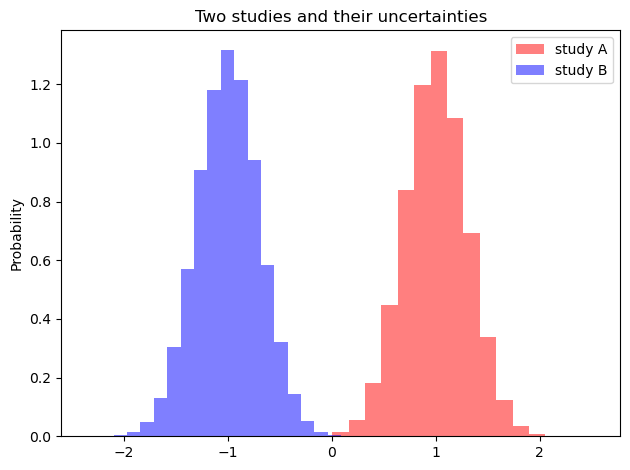

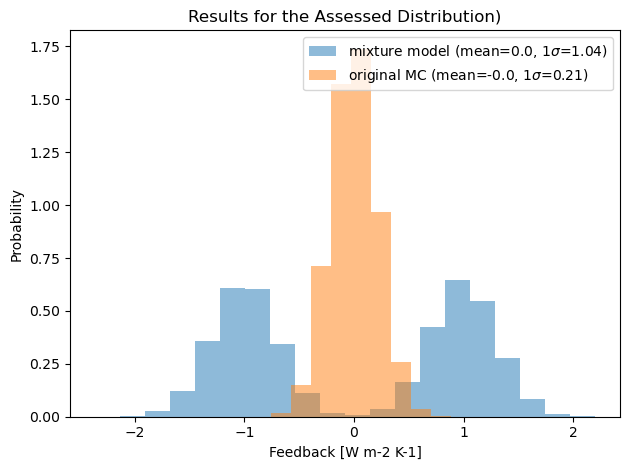

In [10]:
## mixture model
mcn = 100000
sig = 0.3
pos =  np.random.normal( 1.0,sig,mcn)
neg =  np.random.normal(-1.0,sig,mcn)

plt.hist(pos,density=True,label='study A',color='r',bins=20,alpha=0.5)
plt.hist(neg,density=True,label='study B',color='b',bins=20,alpha=0.5)
plt.legend()
plt.title('Two studies and their uncertainties')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

# assume weights are 50/50
mcn_A = int(0.5*mcn) # 50% of mc draws are from study A
mcn_B = mcn - mcn_A  # study B gets the remainder

# mixture model builds a distribution by sampling from each study
# according to its weight
mc_A = np.random.choice(pos, size=mcn_A,replace=True)
mc_B = np.random.choice(neg, size=mcn_B,replace=True)
mc_all_mixture = np.hstack([mc_A,mc_B])

mix_mean = np.round(mc_all_mixture.mean(),2)
mix_std  = np.round(mc_all_mixture.std(ddof=1),2)

plt.hist(mc_all_mixture, density=True,
         label=rf'mixture model (mean={mix_mean}, 1$\sigma$={mix_std})',
         bins=20,alpha=0.5)

plt.xlabel('Feedback [W m-2 K-1]')
plt.legend()
plt.title('Results of the Monte Carlo (Mixture Model)')

## original monte carlo
means   = np.array([ 1.0,  -1.0])   # study A, study B from above
sigmas  = np.array([ sig,   sig])
weights = np.array([ mcn_A/mcn,  mcn_B/mcn])

# for every sample, draw once from EACH study then take the weighted average
# shape: (mcn, 2)  — one column per study
draws = np.random.normal(loc=means, scale=sigmas, size=(mcn, 2))
mc_all_original = np.average(draws, axis=1, weights=weights)

orig_mean = np.round(mc_all_original.mean(),2)
orig_std  = np.round(mc_all_original.std(ddof=1),2)

plt.hist(mc_all_original, density=True,
         label=rf'original MC (mean={orig_mean}, 1$\sigma$={orig_std})',
         bins=10,alpha=0.5)

plt.legend()
plt.xlabel('Feedback [W m-2 K-1]')
plt.ylabel('Probability')
plt.title('Results for the Assessed Distribution)')
plt.tight_layout()
plt.show()